In [ ]:
!pip install -q -U google-genai

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.1/53.1 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 724.7/724.7 kB 15.1 MB/s eta 0:00:00


In [ ]:
input_data = {
  "plot": {
    "boundary": [
      [0.0, 8.957464252365753],
      [9.439352894201875, 48.370306961471215],
      [40.50688146986067, 41.20433556032367],
      [28.55783201754093, 0.0],
      [0.0, 8.957464252365753]
    ],
    "area_sqft": 13863.05
  },

  "edges": [
    {
      "index": 0,
      "start": [0.0, 8.957464252365753],
      "end": [9.439352894201875, 48.370306961471215],
      "length_m": 40.53,
      "sunlight": "soft",
      "wind_role": "neutral",
      "is_frontage": True
    },
    {
      "index": 1,
      "start": [9.439352894201875, 48.370306961471215],
      "end": [40.50688146986067, 41.20433556032367],
      "length_m": 31.88,
      "sunlight": "strong",
      "wind_role": "outlet",
      "is_frontage": False
    },
    {
      "index": 2,
      "start": [40.50688146986067, 41.20433556032367],
      "end": [28.55783201754093, 0.0],
      "length_m": 42.9,
      "sunlight": "harsh",
      "wind_role": "neutral",
      "is_frontage": False
    },
    {
      "index": 3,
      "start": [28.55783201754093, 0.0],
      "end": [0.0, 8.957464252365753],
      "length_m": 29.93,
      "sunlight": "strong",
      "wind_role": "inlet",
      "is_frontage": False
    }
  ],

  "frontage_edge_index": 0,

  "wind": {
    "direction_deg": 90
  },

  "rooms": [
    {"name": "living", "area_sqft": 236.81, "width": 3.4},
    {"name": "dining", "area_sqft": 172.22, "width": 3.0},
    {"name": "family_lounge", "area_sqft": 150.69, "width": 3.0},
    {"name": "bedroom", "area_sqft": 150.69, "width": 2.8},
    {"name": "bedroom", "area_sqft": 129.17, "width": 2.8},
    {"name": "master_bedroom", "area_sqft": 193.75, "width": 3.2 },
    {"name": "kitchen", "area_sqft": 86.11, "width": 2.2},
    {"name": "bathroom", "area_sqft": 53.82, "width": 1.6},
    {"name": "toilet", "area_sqft": 32.29, "width": 1.3}
  ]
}


JSON saved to: /content/plan_dimensions.json


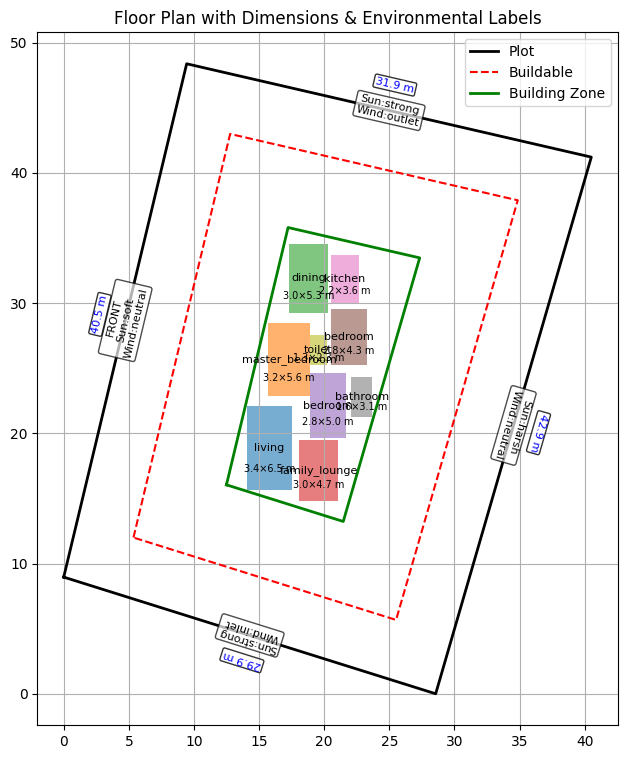

In [ ]:
# =====================================================
# FLOOR PLAN ENGINE (FINAL CLEAN VERSION)
# =====================================================

import json
import os
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import Polygon, box, LineString
from shapely.affinity import translate
from shapely.geometry import JOIN_STYLE

SQFT_TO_M2 = 0.092903
data = input_data

plot_coords = data["plot"]["boundary"]
plot_area_m2 = data["plot"]["area_sqft"] * SQFT_TO_M2
edges = data["edges"]

# =====================================================
# BUILDABLE AREA
# =====================================================

plot_poly = Polygon(plot_coords)
setback = 3.0 if plot_area_m2 <= 500 else 4.5
buildable = plot_poly.buffer(-setback, join_style=JOIN_STYLE.mitre)

if buildable.is_empty:
    setback *= 0.7
    buildable = plot_poly.buffer(-setback, join_style=JOIN_STYLE.mitre)

# =====================================================
# CORE BUILDING ZONE FOR HUGE PLOTS
# =====================================================

required_area = sum(r["area_sqft"] for r in data["rooms"]) * SQFT_TO_M2

if buildable.area > required_area * 3:
    core = buildable
    while core.area > required_area * 2:
        core = core.buffer(-0.5)
        if core.is_empty:
            core = buildable
            break
    core_buildable = core
else:
    core_buildable = buildable

# =====================================================
# BUILD BLOCKS (HANDLE ATTACHMENT)
# =====================================================

rooms=data["rooms"].copy()
used=set()
blocks=[]

for r in rooms:
    if "attach" in r:
        attach_type=r["attach"]
        target=None
        for b in rooms:
            if b["name"]==attach_type and id(b) not in used:
                target=b
                break
        if target:
            used.add(id(r)); used.add(id(target))
            blocks.append({"type":"pair","room":r,"attach":target})

for r in rooms:
    if id(r) not in used:
        blocks.append({"type":"single","room":r})

# =====================================================
# GRID GENERATOR
# =====================================================

def make_candidates(grid):
    minx,miny,maxx,maxy=core_buildable.bounds
    return [
        (x,y)
        for x in np.arange(minx,maxx,grid)
        for y in np.arange(miny,maxy,grid)
        if core_buildable.contains(box(x,y,x+0.2,y+0.2))
    ]

# =====================================================
# BUILD BLOCK GEOMETRY
# =====================================================

def build_block(block,scale=1.0):

    if block["type"]=="single":
        r=block["room"]
        w=r["width"]*scale
        h=(r["area_sqft"]*SQFT_TO_M2)/r["width"]*scale
        return [(r["name"],box(0,0,w,h))]

    r=block["room"]
    b=block["attach"]

    w1=r["width"]*scale
    h1=(r["area_sqft"]*SQFT_TO_M2)/r["width"]*scale

    w2=b["width"]*scale
    h2=(b["area_sqft"]*SQFT_TO_M2)/b["width"]*scale

    room_poly=box(0,0,w1,h1)
    bath_poly=box(w1,0,w1+w2,h2)

    return [(r["name"],room_poly),(b["name"],bath_poly)]

# =====================================================
# PLACE BLOCKS
# =====================================================

placed=[]
occupied=[]

for block in sorted(
        blocks,
        key=lambda x: x["room"]["area_sqft"]
        if x["type"]=="single"
        else x["room"]["area_sqft"]+x["attach"]["area_sqft"],
        reverse=True):

    for scale in [1.0,0.95,0.9,0.85]:
        shapes=build_block(block,scale)

        for grid in [0.8,0.5,0.35]:
            candidates=make_candidates(grid)

            for x,y in candidates:
                moved=[(n,translate(p,xoff=x,yoff=y)) for n,p in shapes]

                union=moved[0][1]
                for _,p in moved[1:]:
                    union=union.union(p)

                if not core_buildable.contains(union): continue
                if any(union.intersects(o) for o in occupied): continue

                for n,p in moved:
                    placed.append((n,p))
                    occupied.append(p)
                break
            else: continue
            break
        else: continue
        break

# =====================================================
# JSON OUTPUT (DIMENSIONS)
# =====================================================

def plot_lengths(coords):
    L=[]
    for i in range(len(coords)-1):
        x1,y1=coords[i]; x2,y2=coords[i+1]
        L.append(round(np.hypot(x2-x1,y2-y1),2))
    return L

dimension_json={
    "plot":{
        "area_m2": round(plot_poly.area,2),
        "side_lengths_m": plot_lengths(plot_coords)
    },
    "rooms":[]
}

for name,poly in placed:
    minx,miny,maxx,maxy=poly.bounds
    dimension_json["rooms"].append({
        "label":name,
        "width_m":round(maxx-minx,2),
        "height_m":round(maxy-miny,2),
        "area_m2":round(poly.area,2)
    })

output_path=os.path.join(os.getcwd(),"plan_dimensions.json")
with open(output_path,"w",encoding="utf-8") as f:
    json.dump(dimension_json,f,indent=2)

print("JSON saved to:",output_path)

# =====================================================
# LABEL FUNCTIONS
# =====================================================

def label_edges(ax, edges):
    for e in edges:
        x1,y1=e["start"]; x2,y2=e["end"]
        mx,my=(x1+x2)/2,(y1+y2)/2
        angle=np.degrees(np.arctan2(y2-y1,x2-x1))

        parts=[]
        if e["is_frontage"]: parts.append("FRONT")
        parts.append(f"Sun:{e['sunlight']}")
        parts.append(f"Wind:{e['wind_role']}")

        ax.text(mx,my,"\n".join(parts),
                rotation=angle,
                ha="center",va="center",fontsize=8,
                bbox=dict(boxstyle="round,pad=0.2",fc="white",alpha=0.7))

def label_room_dims(ax, poly):
    minx,miny,maxx,maxy=poly.bounds
    w=maxx-minx; h=maxy-miny
    cx,cy=poly.centroid.x,poly.centroid.y
    ax.text(cx,cy-h*0.25,f"{w:.1f}×{h:.1f} m",
            ha="center",va="center",fontsize=7)

def label_plot_lengths(ax, coords, offset=2):
    for i in range(len(coords)-1):
        x1,y1=coords[i]; x2,y2=coords[i+1]

        mx,my=(x1+x2)/2,(y1+y2)/2
        dx=x2-x1; dy=y2-y1
        L=np.hypot(dx,dy)

        nx=-dy/L; ny=dx/L
        lx=mx+nx*offset
        ly=my+ny*offset

        angle=np.degrees(np.arctan2(dy,dx))

        ax.text(lx,ly,f"{L:.1f} m",
                rotation=angle,
                ha="center",va="center",
                fontsize=8,color="blue",
                bbox=dict(boxstyle="round,pad=0.15",fc="white",alpha=0.8))

# =====================================================
# DRAW
# =====================================================

fig,ax=plt.subplots(figsize=(9,9))

px,py=plot_poly.exterior.xy
ax.plot(px,py,"k-",lw=2,label="Plot")

bx,by=buildable.exterior.xy
ax.plot(bx,by,"r--",label="Buildable")

cx,cy=core_buildable.exterior.xy
ax.plot(cx,cy,"g-",lw=2,label="Building Zone")

for name,poly in placed:
    x,y=poly.exterior.xy
    ax.fill(x,y,alpha=0.6)
    ax.text(poly.centroid.x,poly.centroid.y,name,
            ha="center",va="center",fontsize=8)
    label_room_dims(ax,poly)

label_edges(ax,edges)
label_plot_lengths(ax,plot_coords)

ax.set_aspect("equal")
ax.set_title("Floor Plan with Dimensions & Environmental Labels")
ax.legend()
ax.grid(True)

plt.savefig("plan2.png",dpi=300,bbox_inches="tight")
plt.show()


In [ ]:
import os
from google import genai
from google.genai import types
from PIL import Image
from io import BytesIO

# 1. Initialize the Client
# Replace 'YOUR_API_KEY' or set it as an environment variable
client = genai.Client(api_key='you api key')

def edit_image(image_path, prompt, output_filename="output_image.png"):
    # 2. Load your reference image
    try:
        ref_image = Image.open(image_path)
    except FileNotFoundError:
        print(f"Error: The file {image_path} was not found.")
        return

    # 3. Call the model (gemini-2.5-flash-image)
    # This model supports both text prompts and image inputs for editing
    response = client.models.generate_content(
        model="gemini-3-pro-image-preview",
        contents=[prompt, ref_image],
        config=types.GenerateContentConfig(
            response_modalities=["IMAGE"], # Ensure it returns an image
        )
    )

    # 4. Handle and save the output
    for part in response.candidates[0].content.parts:
        if part.inline_data:
            # Convert bytes back to an image
            generated_img = Image.open(BytesIO(part.inline_data.data))
            generated_img.save(output_filename)
            generated_img.show()
            print(f"Success! Image saved as {output_filename}")
            return

    print("No image was generated. Check your prompt or safety filters.")

# --- Execute ---
# Provide your image path and what you want to change
edit_image(
    image_path="plan2.png",
    # prompt="convert this to a professional 2D architectural floor plan , top-down perspective, created in AutoCAD style. The drawing must be on a clean white paper background with sharp black lines. Features: add professional CAD blocks for furniture (beds, sofas, dining table), bathroom fixtures (toilets, sinks), and kitchen counters. Include standard architectural symbols for swing doors and windows. Add dummy dimension lines with numerical labels in feet/inches and clear room text labels using a technical sans-serif font. High-contrast, blueprint aesthetic, clean lines, no shading, architectural technical drawing, 8k resolution.Strictly follow the given image for number of partitions(suchas bathroom bedrooms,kitchen etc...),mark wind ,sun,frontage information from the image while drawing,opening of living must face frontage"
     prompt = """
ACT AS A PROFESSIONAL ARCHITECTURAL DRAFTSMAN.
Convert the provided sketch into a precision 2D architectural floor plan in a professional AutoCAD style.

### SOURCE HIERARCHY & LOGIC ###
1. VISUAL REFERENCE (THE IMAGE):
   - Use the image to identify the spatial arrangement of rooms.
   - Extract the 'Frontage', 'Sun direction', and 'Wind direction' markings.
   - Observe the 'Red Dotted Setback' lines; the final plan must fit strictly inside them.
   - POSITIONING: The Living Room's primary opening/entrance must face the 'Frontage' indicated in the image.

2. TECHNICAL SPECIFICATIONS (THE JSON):
   - Use the JSON data for all measurements and dimensions.
   - Apply the specific room dimensions, wall thicknesses, and total plot area from the JSON to the layout found in the image.
   - MASTER DATA: {json_data}

### DRAFTING REQUIREMENTS ###
• TOP-DOWN VIEW: 2D orthographic projection only. No perspective or 3D angles.
• WALLS: Render structural walls with thicknesses specified in JSON (e.g., 9" exterior, 4.5" interior). Use clean, double-line drafting.

• OPENINGS: Represent the Living Room opening, all doors, and windows using standard CAD symbols.

• ANNOTATIONS:
  - Mark 'N' (North/Frontage), 'W' (Wind), and 'S' (Sun) exactly as positioned in the sketch.
  - Add dimension lines with architectural tick marks using the numerical values from the JSON.

  - Label each room with a technical sans-serif font.

### STYLE & FINISH ###
• Aesthetic: Clean AutoCAD / Vector-style drafting.
• Colors: Strictly black lines on a solid white background.
• NO SHADING: No textures, no furniture shadows, no hand-drawn wobbles.
• Resolution: High-contrast, crisp, professional technical drawing.
""")

Success! Image saved as output_image.png


In [ ]:
    # prompt="convert this to a professional 2D architectural floor plan , top-down perspective, created in AutoCAD style. The drawing must be on a clean white paper background with sharp black lines. Features: add professional CAD blocks for furniture (beds, sofas, dining table), bathroom fixtures (toilets, sinks), and kitchen counters. Include standard architectural symbols for swing doors and windows. Add dummy dimension lines with numerical labels in feet/inches and clear room text labels using a technical sans-serif font. High-contrast, blueprint aesthetic, clean lines, no shading, architectural technical drawing, 8k resolution.Strictly follow the given image for number of partitions(suchas bathroom bedrooms,kitchen etc...),mark wind ,sun,frontage information from the image while drawing,opening of living must face frontage"


In [ ]:
import os
import json # Added for handling the data
from google import genai
from google.genai import types
from PIL import Image
from io import BytesIO

# 1. Initialize the Client
client = genai.Client(api_key='your api key')

def edit_image_with_json(image_path, prompt, metadata_json, output_filename="output_image.png"):
    # 2. Load your reference image
    try:
        ref_image = Image.open(image_path)
    except FileNotFoundError:
        print(f"Error: The file {image_path} was not found.")
        return

    # --- NEW: Process JSON Data ---
    # Convert the JSON dictionary into a readable string for the prompt
    json_info = json.dumps(metadata_json, indent=4)
    enhanced_prompt = f"{prompt}\n\nStrictly adhere to the following technical specifications provided in JSON format:\n{json_info}"

    # 3. Call the model
    # Note: Ensure the model name is correct for your environment
    response = client.models.generate_content(
        model="gemini-3-pro-image-preview",
        contents=[enhanced_prompt, ref_image],
        config=types.GenerateContentConfig(
            response_modalities=["IMAGE"],
        )
    )

    # 4. Handle and save the output
    if response.candidates and response.candidates[0].content.parts:
        for part in response.candidates[0].content.parts:
            if part.inline_data:
                generated_img = Image.open(BytesIO(part.inline_data.data))
                generated_img.save(output_filename)
                generated_img.show()
                print(f"Success! Image saved as {output_filename}")
                return

    print("No image was generated. Check your prompt or safety filters.")

# --- Execute ---
# Example JSON with specific architectural data
json_file_path = "/content/plan2.json"

def load_json_data(path):
    try:
        with open(path, 'r') as f:
            return json.load(f)
    except FileNotFoundError:
        print(f"Error: {path} not found. Did you upload it to Colab?")
        return None

# 2. Load the data
architectural_data = load_json_data(json_file_path)

# Updated base_prompt with a placeholder for the JSON data
base_prompt = """
ACT AS A PROFESSIONAL ARCHITECTURAL DRAFTSMAN.
Convert the provided sketch into a precision 2D architectural floor plan in a professional AutoCAD style.

### SOURCE HIERARCHY & LOGIC ###
1. VISUAL REFERENCE (THE IMAGE):
   - Use the image to identify the spatial arrangement of rooms.
   - Extract the 'Frontage', 'Sun direction', and 'Wind direction' markings.
   - Observe the 'Red Dotted Setback' lines; the final plan must fit strictly inside them.
   - POSITIONING: The Living Room's primary opening/entrance must face the 'Frontage' indicated in the image.

2. TECHNICAL SPECIFICATIONS (THE JSON):
   - Use the JSON data for all measurements and dimensions.
   - Apply the specific room dimensions, wall thicknesses, and total plot area from the JSON to the layout found in the image.
   - MASTER DATA: {json_data}

### DRAFTING REQUIREMENTS ###
• TOP-DOWN VIEW: 2D orthographic projection only. No perspective or 3D angles.
• WALLS: Render structural walls with thicknesses specified in JSON (e.g., 9" exterior, 4.5" interior). Use clean, double-line drafting.

• OPENINGS: Represent the Living Room opening, all doors, and windows using standard CAD symbols.

• ANNOTATIONS:
  - Mark 'N' (North/Frontage), 'W' (Wind), and 'S' (Sun) exactly as positioned in the sketch.
  - Add dimension lines with architectural tick marks using the numerical values from the JSON.

  - Label each room with a technical sans-serif font.

### STYLE & FINISH ###
• Aesthetic: Clean AutoCAD / Vector-style drafting.
• Colors: Strictly black lines on a solid white background.
• NO SHADING: No textures, no furniture shadows, no hand-drawn wobbles.
• Resolution: High-contrast, crisp, professional technical drawing.
"""

if architectural_data:
    edit_image_with_json(
        image_path="plan2.png",
        prompt=base_prompt,
        metadata_json=architectural_data
    )

Success! Image saved as output_image.png
